[[  0   1]
 [  0   1]
 [  0   2]
 [  0   4]
 [  0   7]
 [  0  11]
 [  0  12]
 [  0  16]
 [  0  19]
 [  0  23]
 [  0  26]
 [  0  30]
 [  0  34]
 [  0  38]
 [  0  41]
 [  0  43]
 [  0  46]
 [  0  50]
 [  0  55]
 [  0  59]
 [  0  63]
 [  0  68]
 [  0  72]
 [  0  76]
 [  0  79]
 [  0  83]
 [  0  87]
 [  0  90]
 [  0  93]
 [  0  96]
 [  0  99]
 [  0 101]
 [  0 104]
 [  0 106]
 [  1 109]
 [  1 111]
 [  1 113]
 [  2 116]
 [  2 118]
 [  3 119]
 [  4 121]
 [  5 123]
 [  6 124]
 [  7 126]
 [  9 128]
 [ 11 129]
 [ 13 131]
 [ 15 132]
 [ 17 134]
 [ 19 135]
 [ 21 136]
 [ 23 137]
 [ 26 138]
 [ 27 139]
 [ 29 140]
 [ 31 141]
 [ 32 142]
 [ 34 143]
 [ 35 144]
 [ 36 145]
 [ 37 146]
 [ 38 146]
 [ 39 147]
 [ 40 148]
 [ 41 148]
 [ 42 149]
 [ 43 150]
 [ 44 150]
 [ 45 151]
 [ 45 152]
 [ 46 152]
 [ 47 153]
 [ 48 153]
 [ 49 154]
 [ 50 155]
 [ 50 155]
 [ 51 156]
 [ 52 156]
 [ 53 157]
 [ 54 158]
 [ 55 159]
 [ 56 159]
 [ 57 160]
 [ 58 161]
 [ 59 162]
 [ 60 162]
 [ 61 163]
 [ 62 164]
 [ 63 164]
 [ 64 165]
 [ 65 166]

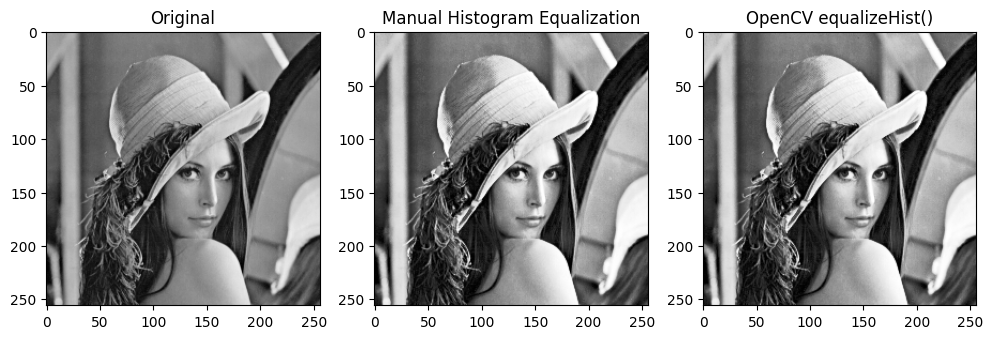

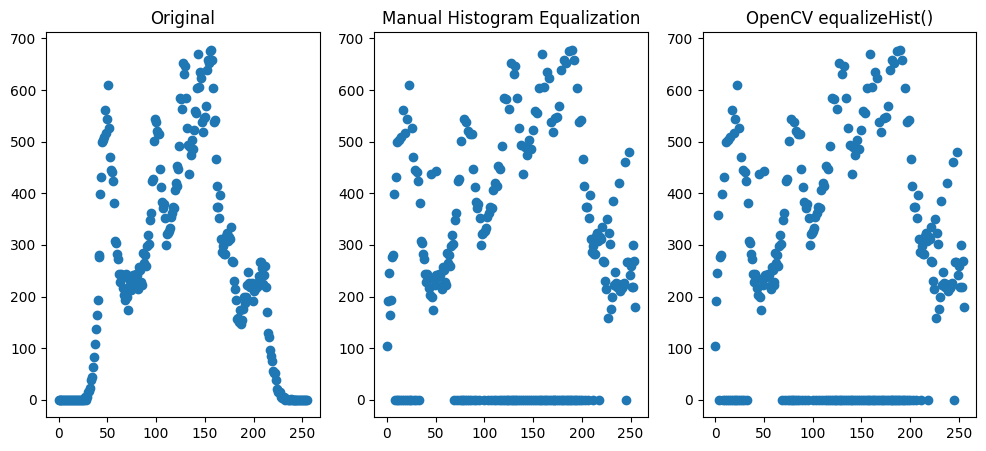

In [3]:
############## Histogram Specification ############

import cv2
import numpy as np
import matplotlib.pyplot as plt


original = cv2.imread("/content/original.jpg", cv2.IMREAD_GRAYSCALE)
target = cv2.imread("/content/target.jpg", cv2.IMREAD_GRAYSCALE)
original = cv2.resize(original, (256,256))
target = cv2.resize(target, (256,256))
cv2.imwrite('original_scaled.jpg', original)
cv2.imwrite('target_scaled.jpg', target)







def hist_equalization(original):

  hist_org = np.zeros(256, dtype=int)


  row, col = original.shape

  for i in range(row):
    for j in range(col):
      hist_org[original[i,j]]+=1


  pdf = hist_org / float(row*col)
  cdf = np.zeros(256, dtype=float)
  cdf[0] = pdf[0]
  for i in range(1,256):
    cdf[i] = cdf[i-1] + pdf[i]

  mapping = np.round(cdf * 255).astype(np.uint8)

  output = np.zeros_like(original)
  for i in range(row):
    for j in range(col):
      output[i,j] = mapping[original[i,j]]

  hist_output = np.zeros(256, dtype=int)
  row, col = output.shape
  for i in range(row):
    for j in range(col):
      hist_output[output[i,j]]+=1

  return output, mapping

original_eq, original_mapping = hist_equalization(original)
target_eq, target_mapping = hist_equalization(target)




### Step 3: Mapping of histogram specified pixels

merged_mapping = np.zeros(256, dtype=np.uint8)

for i in range(256):
    # Find the index in target_mapping whose value is closest to original_mapping[i]
    diffs = np.abs(target_mapping - original_mapping[i])
    closest_match_intensity = np.argmin(diffs)
    merged_mapping[i] = closest_match_intensity










hist_org = np.zeros(256, dtype=int)


row, col = original.shape

for i in range(row):
  for j in range(col):
    hist_org[original[i,j]]+=1


pdf = hist_org / float(row*col)

# print(original.shape)
# print(hist_org)
# print(pdf)

cdf = np.zeros(256, dtype=float)
cdf[0] = pdf[0]
for i in range(1,256):
  cdf[i] = cdf[i-1] + pdf[i]

mapping = np.round(cdf * 255).astype(np.uint8)

# print(mapping)

output = np.zeros_like(original)
for i in range(row):
  for j in range(col):
    output[i,j] = mapping[original[i,j]]

hist_output = np.zeros(256, dtype=int)
row, col = output.shape
for i in range(row):
  for j in range(col):
    hist_output[output[i,j]]+=1


cv2.imwrite('equalized_lena.jpg', output)






####### using builtin function ##########
output_cv = cv2.equalizeHist(original)

hist_output_cv = np.zeros(256, dtype=int)
row, col = output_cv.shape
for i in range(row):
  for j in range(col):
    hist_output_cv[output_cv[i,j]]+=1

cv2.imwrite('cv_equalized_lena.jpg', output_cv)







plt.figure(figsize=(12,5))

plt.subplot(1, 3, 1)
plt.imshow(original, cmap='gray')
plt.title('Original')


plt.subplot(1, 3, 2)
plt.imshow(output, cmap='gray')
plt.title('Manual Histogram Equalization')


plt.subplot(1, 3, 3)
plt.imshow(output_cv, cmap='gray')
plt.title('OpenCV equalizeHist()')





plt.figure(figsize=(12,5))
x_values = np.arange(256)

plt.subplot(1, 3, 1)
plt.scatter(x_values, hist_org)
plt.title('Original')


plt.subplot(1, 3, 2)
plt.scatter(x_values, hist_output)
plt.title('Manual Histogram Equalization')


plt.subplot(1, 3, 3)
plt.scatter(x_values, hist_output_cv)
plt.title('OpenCV equalizeHist()')

plt.show()